## Custom SNN LIF neuron Python implementation for electronics engineering bachelor project

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import copy
import itertools

# Custom neuron implelmentation
from LIF import LIF

# Set random seed for reproducability
np.random.seed(42)

### Simulation Setup

In [ ]:
pattern_box_open_right = [np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
    1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
]), 0]

pattern_box_open_left = [np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
]), 1]

pattern_box_open_top = [np.array([
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
]), 2]

pattern_box_open_bottom = [np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1
]), 3]

# rSTDP

### Simulation setup

**Parameters for grid search**

In [87]:
# Architecture parameters
hidden_layers_range = [0, 1, 2]
hidden_size_range = [25, 50, 100, 250]

# Hyperparameters
beta_range = [0.999]
threshold_range = [2.5, 3.0]                
reset_val = 0.0
learning_rate_range = [0.01, 0.05, 0.1]      
initial_weight_range = [0.25, 0.5]          

# Reward parameters
dopamine_correct_range = [2.5, 5.0, 7.5]
dopamine_wrong_range = [-0.25, -0.5, -1.0]
dopamine_nofire_range = [-0.05, -0.1]

# Decay parameters
global_weight_decay_range = [0.99, 1.0]
threshold_decay_range = [0.002, 0.01, 0.05]

# Threshold parameters
threshold_increase_winner_range = [1.5, 3.0, 5.0]

# Pattern settings
pattern_hold_duration = 25
input_size = 15*15
output_size = 4

# Define patterns
patterns = [
    (pattern_box_open_right[0], 0),
    (pattern_box_open_left[0], 1),
    (pattern_box_open_top[0], 2),
    (pattern_box_open_bottom[0], 3)
]

# Calculate total combinations
total_combinations = len(list(itertools.product(
    beta_range, threshold_range, learning_rate_range, initial_weight_range,
    dopamine_correct_range, dopamine_wrong_range, dopamine_nofire_range,
    global_weight_decay_range, threshold_decay_range, threshold_increase_winner_range,
    hidden_layers_range, hidden_size_range
)))

results_snn = []
n_runs = 3
time_steps = 1000

for config in tqdm(itertools.product(
    beta_range, threshold_range, learning_rate_range, initial_weight_range,
    dopamine_correct_range, dopamine_wrong_range, dopamine_nofire_range,
    global_weight_decay_range, threshold_decay_range, threshold_increase_winner_range,
    hidden_layers_range, hidden_size_range
), total=total_combinations):
    
    (b, thresh, lr, init_w, d_corr, d_wrng, d_nofi, w_decay, t_decay, t_inc, n_hidden, h_size) = config

    run_accuracies = []

    for run in range(n_runs):
        # Initialize Network Architecture
        if n_hidden == 0:
            # Direct input → output
            weights = [np.full((input_size, output_size), init_w)]
            layers = [
                [LIF(beta=b, threshold=thresh, learning_rate=lr, reset=reset_val) for _ in range(input_size)],
                [LIF(beta=b, threshold=thresh, learning_rate=lr, reset=reset_val) for _ in range(output_size)]
            ]
        else:
            # Input → hidden(s) → output
            layers = [[LIF(beta=b, threshold=thresh, learning_rate=lr, reset=reset_val) for _ in range(input_size)]]
            weights = [np.full((input_size, h_size), init_w)]
            
            # Add first hidden layer
            layers.append([LIF(beta=b, threshold=thresh, learning_rate=lr, reset=reset_val) for _ in range(h_size)])
            
            # Add additional hidden layers
            for _ in range(n_hidden - 1):
                layers.append([LIF(beta=b, threshold=thresh, learning_rate=lr, reset=reset_val) for _ in range(h_size)])
                weights.append(np.full((h_size, h_size), init_w))
            
            # Add output layer
            layers.append([LIF(beta=b, threshold=thresh, learning_rate=lr, reset=reset_val) for _ in range(output_size)])
            weights.append(np.full((h_size, output_size), init_w))
        
        output_neurons = layers[-1]
        final_weights = weights[-1]
        
        correct_count = 0
        total_spike_events = 0

        # Training Loop
        for t in range(time_steps):
            pattern_idx = (t // pattern_hold_duration) % 4
            input_spikes, correct_output = patterns[pattern_idx]

            # Forward pass through all layers
            for l in range(len(layers)):
                if l == 0:
                    # Update input layer
                    for i in range(len(layers[0])):
                        layers[0][i].update(input_spikes[i])
                else:
                    # Update hidden/output layers
                    for j in range(len(layers[l])):
                        synaptic_input = np.dot(weights[l-1][:, j], [n.spk for n in layers[l-1]])
                        layers[l][j].update(synaptic_input)

            # Winner-Take-All on output layer
            fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
            winner_idx = -1
            if len(fired_indices) > 0:
                winner_idx = np.random.choice(fired_indices)
                total_spike_events += 1
                if winner_idx == correct_output:
                    correct_count += 1
                
                for j in range(output_size):
                    if j != winner_idx:
                        output_neurons[j].spk = 0
                        output_neurons[j].mem *= 0.5
                    else:
                        output_neurons[j].threshold += t_inc

            # Reward Calculation
            if winner_idx == correct_output:
                dopamine = d_corr
            elif winner_idx == -1:
                dopamine = d_nofi
            else:
                dopamine = d_wrng

            # R-STDP & Competitive Learning on final layer only
            pre_layer = layers[-2]
            if winner_idx != -1:
                for i in range(len(pre_layer)):
                    for j in range(output_size):
                        if j == winner_idx:
                            # Winner strengthens weights
                            final_weights[i,j] = output_neurons[j].rSTDP(
                                final_weights[i,j], 
                                pre_layer[i].eligibility,
                                is_winner=True,
                                dopamine=dopamine
                            )
                        else:
                            # Non-winners: competitive suppression
                            if dopamine > 0:
                                timing_factor = pre_layer[i].eligibility * pre_layer[i].eligibility
                                final_weights[i,j] -= lr * timing_factor * dopamine * 0.3
                
                # Global weight decay
                final_weights *= w_decay
                # Clip to prevent collapse
                final_weights = np.clip(final_weights, 0.1, 0.9)
                
                # Weight Normalization (Homeostasis)
                for j in range(output_size):
                    target_sum = 6
                    current_sum = np.sum(final_weights[:, j])
                    if current_sum > 0:
                        final_weights[:, j] *= (target_sum / current_sum)
            else:
                for n in output_neurons:
                    n.threshold = max(n.threshold - 0.05, 0.75)

            # Update thresholds
            for j in range(output_size):
                output_neurons[j].update_threshold(threshold_decay=t_decay)

        # Calculate accuracy
        acc = correct_count / total_spike_events if total_spike_events > 0 else 0
        run_accuracies.append(acc)

    # Store Results
    results_snn.append({
        'beta': b,
        'init_threshold': thresh,
        'lr': lr,
        'init_weight': init_w,
        'd_correct': d_corr,
        'd_wrong': d_wrng,
        'd_nofire': d_nofi,
        'w_decay': w_decay,
        't_decay': t_decay,
        't_inc_winner': t_inc,
        'n_hidden_layers': n_hidden,
        'hidden_size': h_size,
        'mean_accuracy': np.mean(run_accuracies),
        'std_accuracy': np.std(run_accuracies)
    })

# Save results
df_results = pd.DataFrame(results_snn)
df_results.to_csv("SNN_GridSearch_Results.csv", index=False)

100%|██████████| 46656/46656 [60:20:11<00:00,  4.66s/it]    


In [88]:
# Load the grid search results
df = pd.read_csv("SNN_GridSearch_Results.csv")

# Identify Top 25 configurations by mean accuracy
top_25 = df.sort_values(by=['mean_accuracy', 'std_accuracy'], ascending=[False, True]).head(25)

print("=== Top 25 SNN Configurations ===")
print(top_25[['mean_accuracy', 'std_accuracy', 'beta', 'init_threshold', 'init_weight', 
              'd_correct', 'd_wrong', 'd_nofire', 't_inc_winner', 'w_decay', 't_decay', 
              'lr', 'n_hidden_layers', 'hidden_size']])

# Analyze impact of key parameters
print("\n=== Impact of Punishment (d_wrong) on Accuracy ===")
print(df.groupby('d_wrong')['mean_accuracy'].mean())

print("\n=== Impact of Threshold Increase on Accuracy ===")
print(df.groupby('t_inc_winner')['mean_accuracy'].mean())

print("\n=== Impact of Architecture on Accuracy ===")
print(df.groupby(['n_hidden_layers', 'hidden_size'])['mean_accuracy'].mean())

print("\n=== Impact of Initial Weight on Accuracy ===")
print(df.groupby('init_weight')['mean_accuracy'].mean())

print("\n=== Impact of Threshold on Accuracy ===")
print(df.groupby('init_threshold')['mean_accuracy'].mean())

# Filter for stable high performers
stable_high_performers = df[(df['mean_accuracy'] > 0.8) & (df['std_accuracy'] < 0.05)]

if not stable_high_performers.empty:
    print("\n=== Most Stable High-Performing Config ===")
    print(stable_high_performers.sort_values(by='mean_accuracy', ascending=False).iloc[0])
else:
    print("\n=== No configs with >80% accuracy and <5% std found ===")

=== Top 25 SNN Configurations ===
       mean_accuracy  std_accuracy   beta  init_threshold  init_weight  \
18601       0.321552      0.015403  0.999             2.5         0.25   
18182       0.321391      0.014245  0.999             2.5         0.25   
18315       0.319473      0.011555  0.999             2.5         0.25   
18723       0.315458      0.007854  0.999             2.5         0.25   
43055       0.314700      0.016104  0.999             3.0         0.50   
19273       0.314685      0.021136  0.999             2.5         0.25   
18156       0.314627      0.013726  0.999             2.5         0.25   
23103       0.313648      0.004910  0.999             2.5         0.50   
18386       0.313236      0.010372  0.999             2.5         0.25   
4897        0.312992      0.010037  0.999             2.5         0.50   
19274       0.312921      0.005897  0.999             2.5         0.25   
18927       0.312543      0.013721  0.999             2.5         0.25   
1993

### **Best parameters**

In [129]:
# Simulation parameters
time_steps = 5000
pattern_hold_duration = 250

# Architecture parameter
input_size = 15*15     # Number of input neurons
output_size = 4     # Number of output neurons

# Hyperparameters
beta = 0.999
threshold = 2.5
reset_val = 0.0
learning_rate = 0.1
initial_weight = 0.25

# Reward parameters
dopamine_correct = 7.5
dopamine_wrong = -0.50
dopamine_nofire = -0.05

# Decay parameters
global_weight_decay = 0.99
threshold_decay = 0.002

# Threshold parameters
threshold_increase_winner = 5.0

# Initialize history lists
mem_hist = []
thresh_hist = []
spike_hist = []
target_hist = []


In [130]:

# Instantiate synapses as a weight matrix, with all weights starting at
input_to_output_synapses = np.full((input_size, output_size), 0.1)
#input_to_output_synapses = np.random.rand(input_size, output_size)
print(f"Sucessfully created synapse matrix {input_to_output_synapses.shape}")

# Instantiate layers as litst of neurons
input_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(input_size)]
output_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(output_size)]

print(f"Sucessfully created input layer with {len(input_neurons)}")
print(f"Sucessfully created output layer with {len(output_neurons)}")


Sucessfully created synapse matrix (225, 4)
Sucessfully created input layer with 225
Sucessfully created output layer with 4


In [131]:
# Four patterns
patterns = [
    (pattern_box_open_right[0], 0),
    (pattern_box_open_left[0], 1),
    (pattern_box_open_top[0], 2),
    (pattern_box_open_bottom[0], 3)
]

for t in range(time_steps):
    # Cycle through all 4 patterns
    pattern_idx = (t // pattern_hold_duration) % 4
    input_spikes, correct_output = patterns[pattern_idx]

    # Update input layer neurons
    for i in range(input_size):
        input_neurons[i].update(input_spikes[i])

    # Capture weights before update for diagnostics
    current_weights = input_to_output_synapses.copy()

    # Update output layer neurons
    for j in range(output_size):
        synaptic_input = sum(current_weights[i,j] * input_neurons[i].spk for i in range(input_size))
        output_neurons[j].update(synaptic_input)

    # Apply winner-take-all weight updates
    fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
    winner_idx = -1
    if len(fired_indices) > 0:
        winner_idx = np.random.choice(fired_indices)
        for j in range(output_size):
            if j != winner_idx:
                output_neurons[j].spk = 0
                output_neurons[j].mem = 0
            else:
                output_neurons[j].threshold += threshold_increase_winner

    # Calculate reward based on correct response
    if winner_idx == correct_output:
        dopamine = dopamine_correct
    elif winner_idx == -1:
        # If nothing fired lower slightly
        dopamine = dopamine_nofire
    else:
        # If wrong neuron fired, punish
        dopamine = dopamine_wrong

    # Apply R-STDP with actual reward signal
    if winner_idx != -1:
        for i in range(input_size):
            for j in range(output_size):
                input_to_output_synapses[i,j] = output_neurons[j].rSTDP(
                    input_to_output_synapses[i,j], 
                    input_neurons[i].eligibility,
                    is_winner=(j == winner_idx),
                    dopamine=dopamine
                )
        # Global weight decay
        input_to_output_synapses *= global_weight_decay
        # Clip to prevent collapse
        input_to_output_synapses = np.clip(input_to_output_synapses, 0.1, 0.9)
        # Weight Normalization (Homeostasis)
        for j in range(output_size):
            target_sum = 6
            current_sum = np.sum(input_to_output_synapses[:, j])
            if current_sum > 0:
                input_to_output_synapses[:, j] *= (target_sum / current_sum)
    else:
        for n in output_neurons:
            n.threshold -= 0.05 
            n.threshold = max(n.threshold, 0.75)

    # Update thresholds based on spikes
    for j in range(output_size):
        output_neurons[j].update_threshold(threshold_decay=threshold_decay)

    # Record the state of the output layer at the end of the timestep
    mem_hist.append([n.mem for n in output_neurons])
    thresh_hist.append([n.threshold for n in output_neurons])
    spike_hist.append([n.spk for n in output_neurons])
    target_hist.append(correct_output)

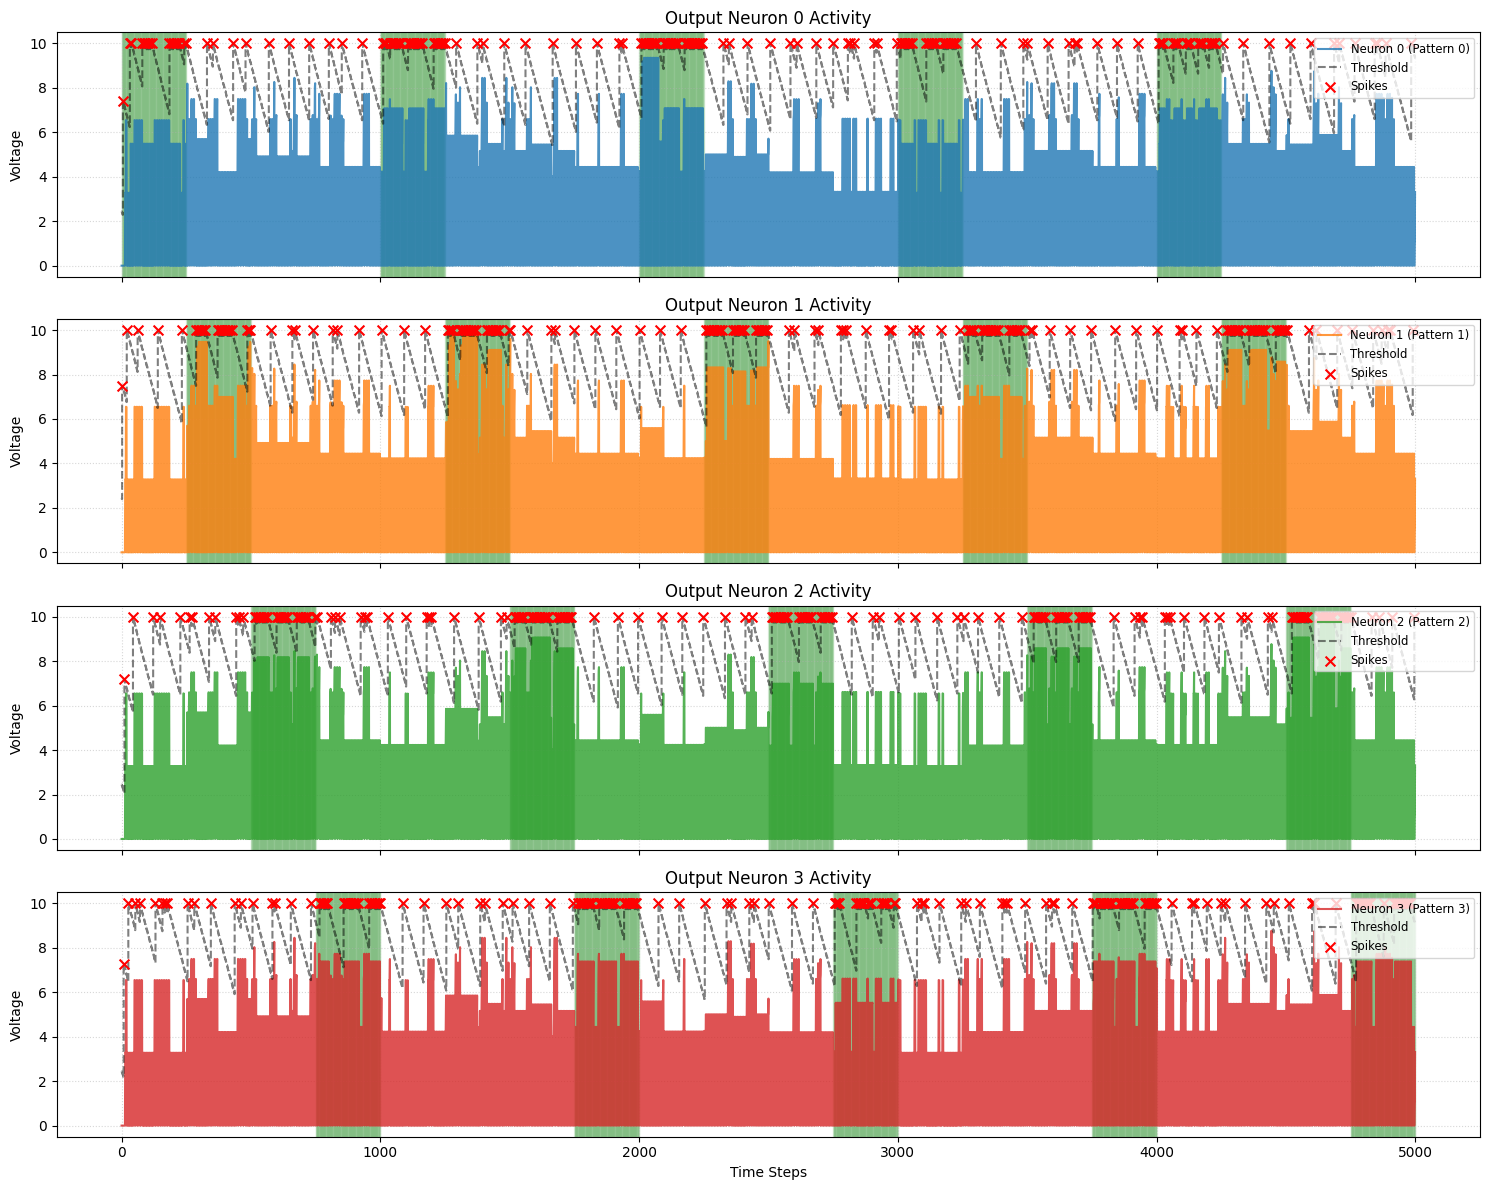


Final Accuracy: 66.9%
Correct: 509/761


In [132]:
import matplotlib.pyplot as plt
import numpy as np

def plot_neuron_dynamics(mem_history, threshold_history, spike_history, target_history):
    time_steps = len(mem_history)
    num_neurons = 4  # Specifically set for your 4-pattern simulation
    
    # Create 4 subplots (one for each neuron)
    fig, axes = plt.subplots(num_neurons, 1, figsize=(15, 12), sharex=True)
    
    # Color palette for 4 distinct neurons
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
    
    for i in range(num_neurons):
        # Extract individual neuron data
        mems = [m[i] for m in mem_history]
        threshs = [t[i] for t in threshold_history]
        spks = [s[i] for s in spike_history]
        
        # 1. Plot Membrane Potential
        axes[i].plot(mems, label=f'Neuron {i} (Pattern {i})', color=colors[i], alpha=0.8)
        
        # 2. Plot Dynamic Threshold
        axes[i].step(range(time_steps), threshs, label='Threshold', color='black', 
                     linestyle='--', alpha=0.5, where='post')
        
        # 3. Plot Spikes (Red 'x')
        spike_times = [t for t, s in enumerate(spks) if s > 0]
        if spike_times:
            # We plot the 'x' at the threshold level at that time
            axes[i].scatter(spike_times, [threshs[t] for t in spike_times], 
                            color='red', marker='x', s=50, label='Spikes', zorder=5)
        
        # 4. Highlight the "Target" period for this specific neuron
        # We only shade green if target_history[t] matches this neuron's index
        for t in range(time_steps):
            if target_history[t] == i:
                axes[i].axvspan(t, t+1, color='green', alpha=0.08)
        
        # Formatting
        axes[i].set_title(f"Output Neuron {i} Activity")
        axes[i].set_ylabel("Voltage")
        axes[i].legend(loc='upper right', fontsize='small')
        axes[i].grid(True, which='both', linestyle=':', alpha=0.5)

    plt.xlabel("Time Steps")
    plt.tight_layout()
    plt.show()

# Run the updated plot
plot_neuron_dynamics(mem_hist, thresh_hist, spike_hist, target_hist)


# Add after your loop
correct_count = 0
total_count = 0

for t in range(len(spike_hist)):
    if any(spike_hist[t]):  # If any neuron fired
        winner = np.argmax(spike_hist[t])
        if winner == target_hist[t]:
            correct_count += 1
        total_count += 1

accuracy = 100 * correct_count / total_count if total_count > 0 else 0
print(f"\nFinal Accuracy: {accuracy:.1f}%")
print(f"Correct: {correct_count}/{total_count}")

In [133]:
# Initialize history lists
mem_hist = []
thresh_hist = []
spike_hist = []
target_hist = []


In [134]:

# Instantiate synapses as a weight matrix, with all weights starting at
input_to_output_synapses = np.full((input_size, output_size), 0.1)
#input_to_output_synapses = np.random.rand(input_size, output_size)
print(f"Sucessfully created synapse matrix {input_to_output_synapses.shape}")

# Instantiate layers as litst of neurons
input_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(input_size)]
output_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(output_size)]

print(f"Sucessfully created input layer with {len(input_neurons)}")
print(f"Sucessfully created output layer with {len(output_neurons)}")


Sucessfully created synapse matrix (225, 4)
Sucessfully created input layer with 225
Sucessfully created output layer with 4


In [135]:
# Four patterns
patterns = [
    (pattern_box_open_right[0], 0),
    (pattern_box_open_left[0], 1),
    (pattern_box_open_top[0], 2),
    (pattern_box_open_bottom[0], 3)
]

for t in range(time_steps):
    # Cycle through all 4 patterns
    pattern_idx = (t // pattern_hold_duration) % 4
    input_spikes, correct_output = patterns[pattern_idx]

    # Update input layer neurons
    for i in range(input_size):
        input_neurons[i].update(input_spikes[i])

    # Capture weights before update for diagnostics
    current_weights = input_to_output_synapses.copy()

    # Update output layer neurons
    for j in range(output_size):
        synaptic_input = sum(current_weights[i,j] * input_neurons[i].spk for i in range(input_size))
        output_neurons[j].update(synaptic_input)

    # Apply winner-take-all weight updates
    fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
    winner_idx = -1
    if len(fired_indices) > 0:
        winner_idx = np.random.choice(fired_indices)
        for j in range(output_size):
            if j != winner_idx:
                output_neurons[j].spk = 0
                output_neurons[j].mem = 0
            else:
                output_neurons[j].threshold += threshold_increase_winner

    # Apply R-STDP with actual reward signal
    if winner_idx != -1:
        for i in range(input_size):
            for j in range(output_size):
                input_to_output_synapses[i,j] = output_neurons[j].STDP(
                    input_to_output_synapses[i,j], 
                    input_neurons[i].eligibility,
                    is_winner=(j == winner_idx),
                )
        # Global weight decay
        input_to_output_synapses *= global_weight_decay
        # Clip to prevent collapse
        input_to_output_synapses = np.clip(input_to_output_synapses, 0.1, 0.9)
        # Weight Normalization (Homeostasis)
        for j in range(output_size):
            target_sum = 6
            current_sum = np.sum(input_to_output_synapses[:, j])
            if current_sum > 0:
                input_to_output_synapses[:, j] *= (target_sum / current_sum)
    else:
        for n in output_neurons:
            n.threshold -= 0.05 
            n.threshold = max(n.threshold, 0.75)

    # Update thresholds based on spikes
    for j in range(output_size):
        output_neurons[j].update_threshold(threshold_decay=threshold_decay)

    # Record the state of the output layer at the end of the timestep
    mem_hist.append([n.mem for n in output_neurons])
    thresh_hist.append([n.threshold for n in output_neurons])
    spike_hist.append([n.spk for n in output_neurons])
    target_hist.append(correct_output)

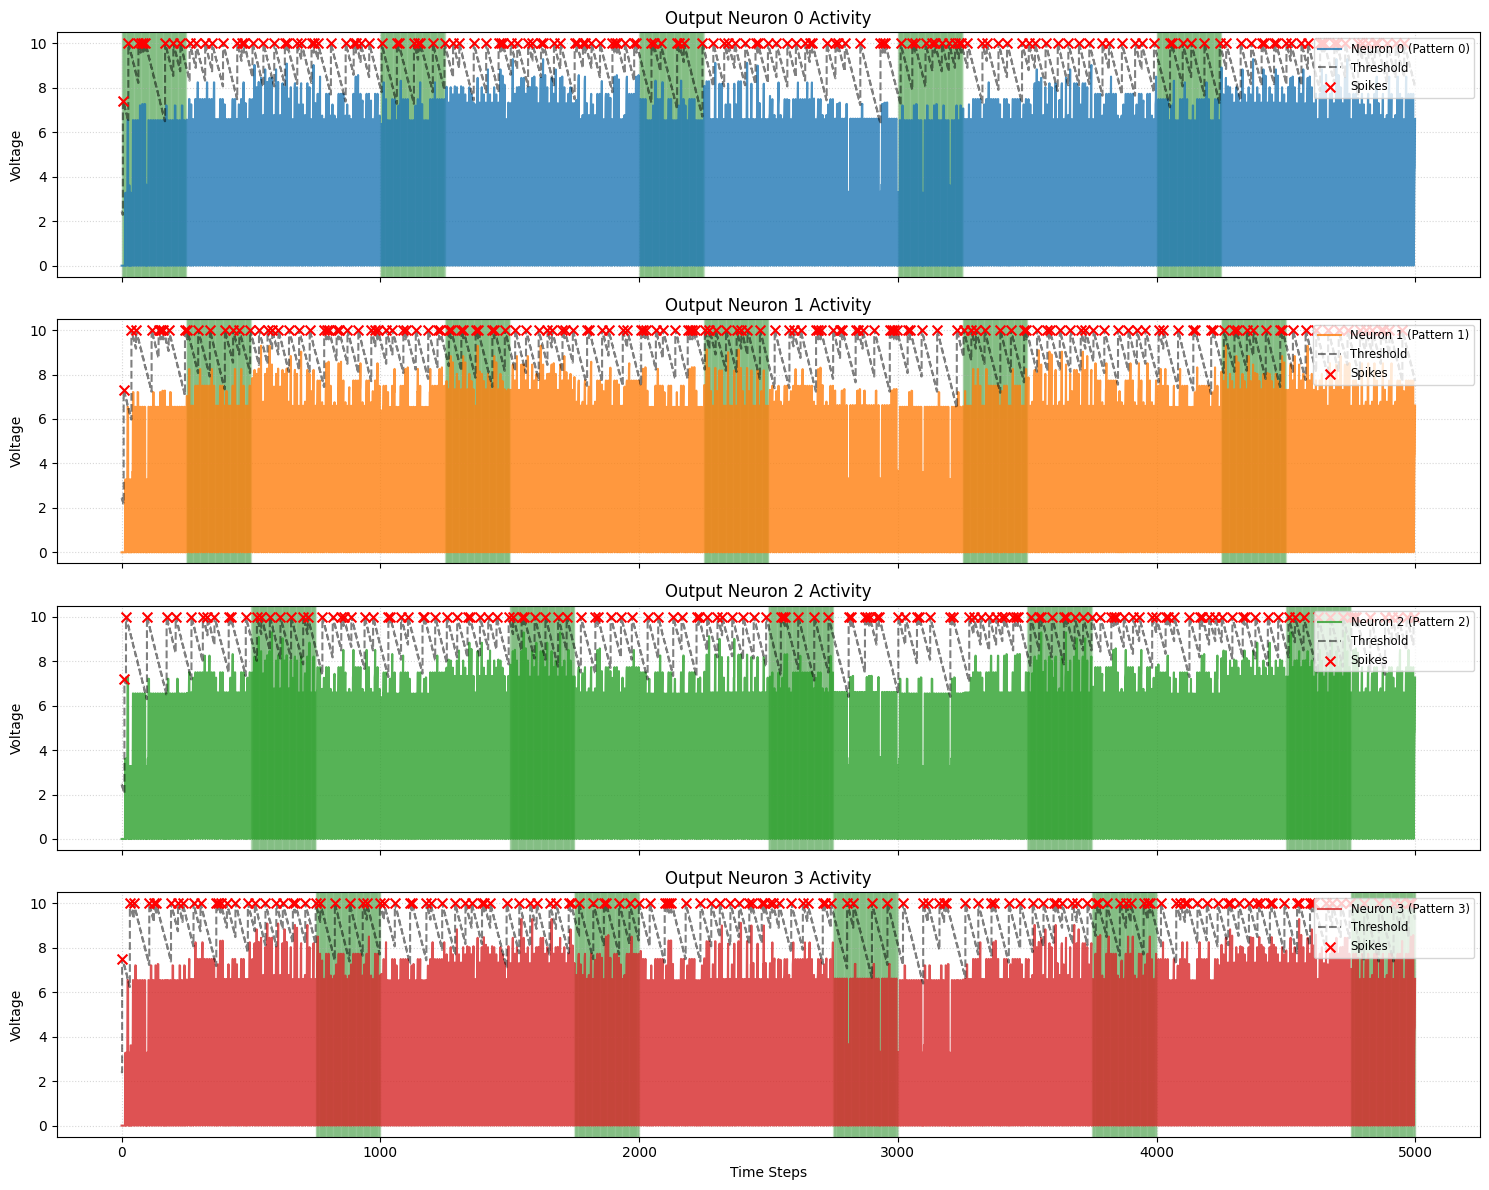


Final Accuracy: 24.6%
Correct: 149/605


In [136]:
# Run the updated plot
plot_neuron_dynamics(mem_hist, thresh_hist, spike_hist, target_hist)


# Add after your loop
correct_count = 0
total_count = 0

for t in range(len(spike_hist)):
    if any(spike_hist[t]):  # If any neuron fired
        winner = np.argmax(spike_hist[t])
        if winner == target_hist[t]:
            correct_count += 1
        total_count += 1

accuracy = 100 * correct_count / total_count if total_count > 0 else 0
print(f"\nFinal Accuracy: {accuracy:.1f}%")
print(f"Correct: {correct_count}/{total_count}")